In [2]:
#Load Libraries 
from rdkit import Chem
from rdkit.Chem import Descriptors, QED, rdMolDescriptors
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams
from rdkit import DataStructs
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from chembl_webresource_client.new_client import new_client

In [3]:
# STEP 1: Load ZINC250K candidates 
url        = "https://raw.githubusercontent.com/aspuru-guzik-group/chemical_vae/master/models/zinc_properties/250k_rndm_zinc_drugs_clean_3.csv"
df         = pd.read_csv(url)
candidates = df["smiles"].tolist()[:1000]
print(f"Candidates loaded: {len(candidates)}")

# STEP 2: Load ChEMBL HMGCR reference set
activity      = new_client.activity
acts          = activity.filter(
                    target_chembl_id = "CHEMBL1781",
                    standard_type    = "IC50"
                ).only("canonical_smiles", "standard_value", "molecule_chembl_id")
chembl_smiles = [a["canonical_smiles"] for a in acts if a["canonical_smiles"]]
print(f"ChEMBL HMGCR compounds: {len(chembl_smiles)}")

# STEP 3: Fingerprint generator 
gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def encode(smi):
    mol = Chem.MolFromSmiles(smi.strip())
    if mol is None: return None
    return gen.GetFingerprint(mol)

# STEP 4: Encode reference set
ref_fps = [encode(s) for s in chembl_smiles]
ref_fps = [fp for fp in ref_fps if fp is not None]
print(f"Valid reference fingerprints: {len(ref_fps)}")

Candidates loaded: 1000
ChEMBL HMGCR compounds: 735
Valid reference fingerprints: 735


In [4]:
# STEP 5: Score all candidates 
results = []
for smi in candidates:
    fp = encode(smi)
    if fp is None: continue
    scores = [DataStructs.TanimotoSimilarity(fp, r) for r in ref_fps]
    results.append({"smiles": smi, "tanimoto": max(scores)})

df_results = pd.DataFrame(results)
print(f"\nAll candidates scored: {len(df_results)}")
print(df_results["tanimoto"].describe())

# STEP 6: Filter to statin-like hits (>0.40) 
hits = df_results[df_results["tanimoto"] > 0.40].copy()
print(f"\nCandidates passing Tanimoto >0.40: {len(hits)}")


All candidates scored: 1000
count    1000.000000
mean        0.225926
std         0.054468
min         0.088235
25%         0.188406
50%         0.220000
75%         0.254902
max         0.444444
Name: tanimoto, dtype: float64

Candidates passing Tanimoto >0.40: 7


In [5]:
# STEP 7: Drug-likeness descriptors on hits
def get_descriptors(smi):
    mol = Chem.MolFromSmiles(smi.strip())
    if mol is None: return None
    mw   = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd  = rdMolDescriptors.CalcNumHBD(mol)
    hba  = rdMolDescriptors.CalcNumHBA(mol)
    qed  = QED.qed(mol)
    viol = sum([mw > 500, logp > 5, hbd > 5, hba > 10])
    return {
        "mw":         round(mw,   2),
        "logp":       round(logp, 2),
        "hbd":        hbd,
        "hba":        hba,
        "qed":        round(qed,  3),
        "violations": viol
    }

#STEP 8: PAINS filter on hits 
params = FilterCatalogParams()
params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
pains  = FilterCatalog(params)

def has_pains(smi):
    mol = Chem.MolFromSmiles(smi.strip())
    if mol is None: return True
    return pains.GetFirstMatch(mol) is not None

hits["desc"]       = hits["smiles"].apply(get_descriptors)
hits               = pd.concat([hits, hits["desc"].apply(pd.Series)], axis=1)
hits               = hits.drop(columns=["desc"])
hits["pains_flag"] = hits["smiles"].apply(has_pains)

# STEP 9: Summary
print("\nDescriptor summary of hits:")
print(hits[["tanimoto","mw","logp","qed","violations"]].describe())

passed_lipinski = (hits["violations"] == 0).sum()
pains_flagged   = hits["pains_flag"].sum()
clean           = ((hits["violations"] == 0) & (~hits["pains_flag"])).sum()

print(f"\nPassed Lipinski (0 violations): {passed_lipinski}")
print(f"PAINS flagged:                  {pains_flagged}")
print(f"Clean candidates:               {clean}")

print("\nAll hits:")
print(hits[["smiles","tanimoto","mw","logp","qed","violations","pains_flag"]])



Descriptor summary of hits:
       tanimoto          mw      logp       qed  violations
count  7.000000    7.000000  7.000000  7.000000    7.000000
mean   0.426837  383.010000  3.904286  0.558286    0.142857
std    0.012147   50.327364  1.234245  0.157459    0.377964
min    0.406250  324.340000  2.360000  0.338000    0.000000
25%    0.421721  348.385000  3.170000  0.505000    0.000000
50%    0.428571  356.420000  3.780000  0.522000    0.000000
75%    0.432576  428.000000  4.350000  0.589000    0.000000
max    0.444444  447.540000  6.150000  0.860000    1.000000

Passed Lipinski (0 violations): 6
PAINS flagged:                  0
Clean candidates:               6

All hits:
                                                smiles  tanimoto      mw  \
16   Cc1ccc(CNC(=O)c2ccccc2NC(=O)[C@@H]2CC(=O)N(c3c...  0.406250  441.53   
536    CC(=O)Nc1ccc(NC(=O)c2ccc3c(c2)Cc2ccccc2-3)cc1\n  0.425532  342.40   
643     COc1cc(OC)cc(C(=O)Nc2ccccc2C(=O)NC(C)(C)C)c1\n  0.431818  356.42   
696     CC(=O

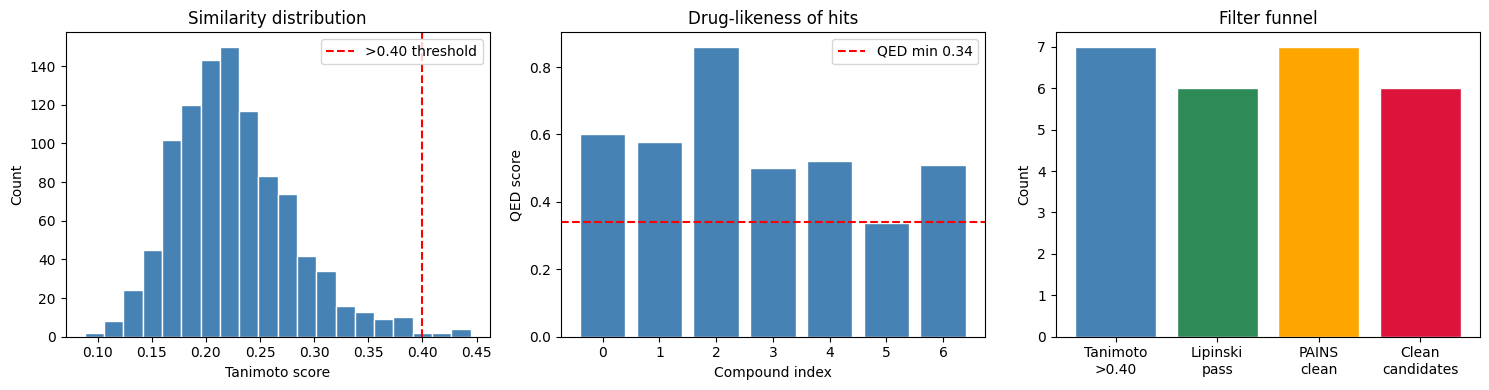

In [6]:
# STEP 10: Visualisations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1 — Tanimoto distribution
axes[0].hist(df_results["tanimoto"], bins=20, color="steelblue", edgecolor="white")
axes[0].axvline(0.40, color="red",    linestyle="--", label=">0.40 threshold")
axes[0].set_xlabel("Tanimoto score")
axes[0].set_ylabel("Count")
axes[0].set_title("Similarity distribution")
axes[0].legend()

# Plot 2 — QED distribution of hits
if len(hits) > 0:
    axes[1].bar(range(len(hits)), hits["qed"], color="steelblue", edgecolor="white")
    axes[1].axhline(0.34, color="red", linestyle="--", label="QED min 0.34")
    axes[1].set_xlabel("Compound index")
    axes[1].set_ylabel("QED score")
    axes[1].set_title("Drug-likeness of hits")
    axes[1].legend()

# Plot 3 — Filter summary
labels  = ["Tanimoto\n>0.40", "Lipinski\npass", "PAINS\nclean", "Clean\ncandidates"]
values  = [len(hits), passed_lipinski, len(hits)-pains_flagged, clean]
colors  = ["steelblue", "seagreen", "orange", "crimson"]
axes[2].bar(labels, values, color=colors, edgecolor="white")
axes[2].set_ylabel("Count")
axes[2].set_title("Filter funnel")

plt.tight_layout()
plt.show()
